# Material for the chapter: Modeling Volatility

In [1]:
%matplotlib inline
import internal_script

import numpy as np
import pandas as pd
import pandas.io.formats.style
import time
import warnings

import dorion_francois.black_merton_scholes as bms
import dorion_francois.dfbook as df # path utils (etc.) for the book
from dorion_francois.hypotheses import moneyness, define_moneyness # Might be moved in the future
from dorion_francois.plot_utils import (
    mpl, plt, mtick, mdates, gridspec,
    set_plt_defaults, set_payoff_axes, set_time_axis, with_style)

import dorion_francois.ch07_modeling_volatility as volm

In [2]:
S = 100
r = 0.05
y = 0.00
T = 0.25 
sigma = 0.20

#define_moneyness('K/S') # Default moneyness requires no additional info
define_moneyness('K/F',r=r,y=y,T=T, sigma=sigma) # Sigma provided for convenience (cf. delta_to_strike)
print('MNY -> K:',moneyness.range(S,0.80,1.21,0.20))

MNY -> K: (array([0.8, 1. , 1.2]), array([ 81.00627612, 101.25784515, 121.50941418]))


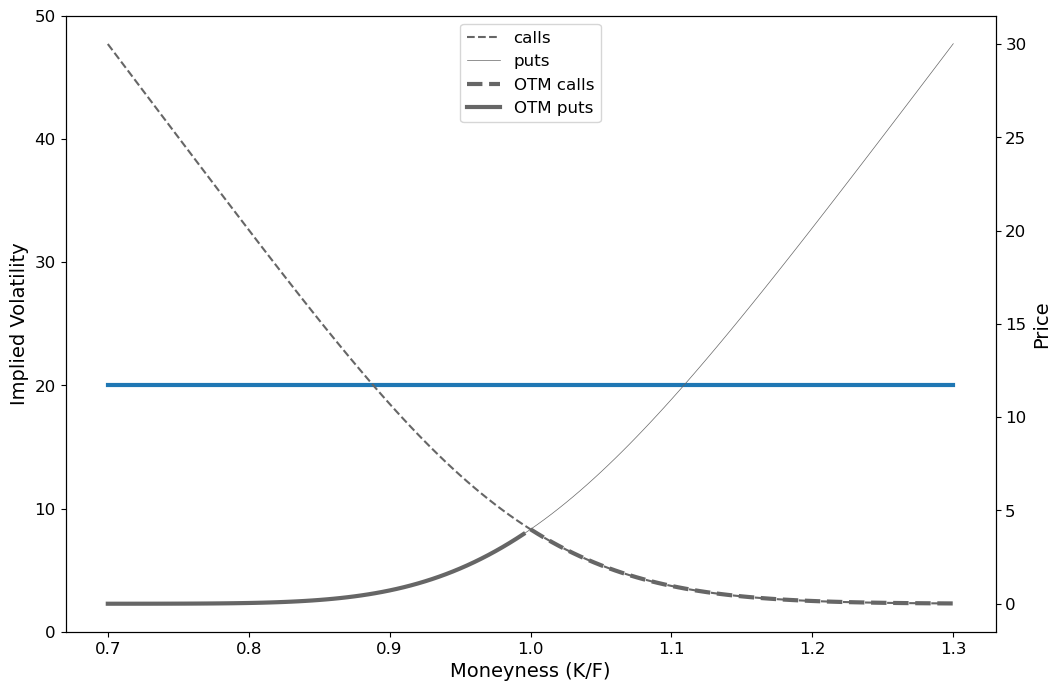

In [3]:
K,calls,puts = volm.fig_no_smile(S, r, y, T, sigma)
df.savefig('modeling_volatility','fig_no_smile.pdf')

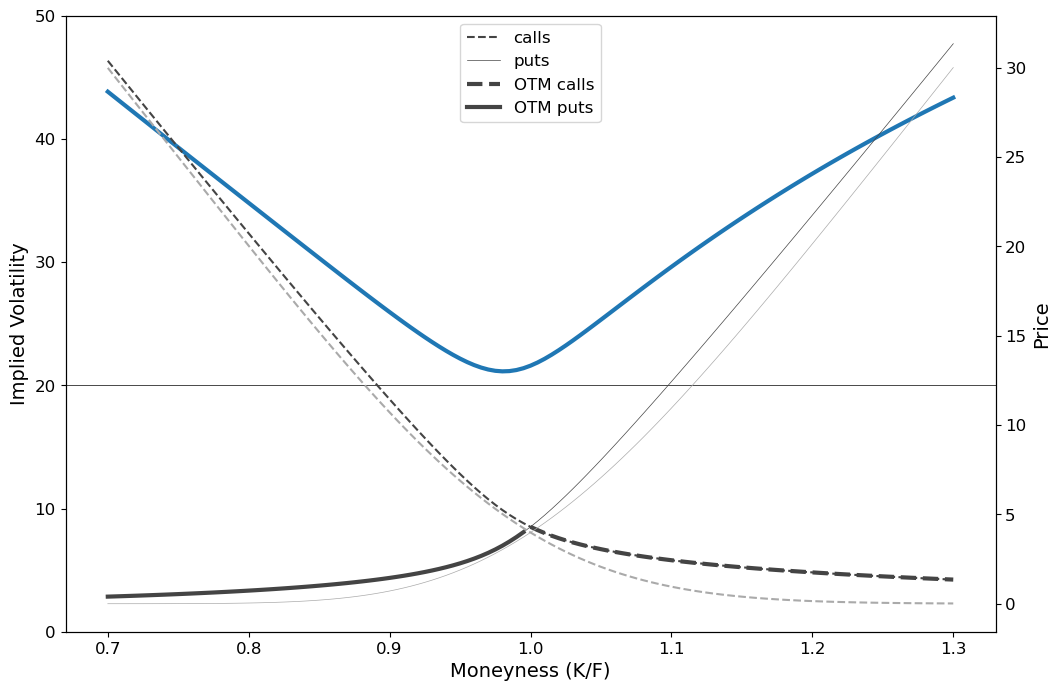

In [4]:
K_sym,c_sym,p_sym = volm.fig_symmetric_smile(S, K, r, y, T, sigma)
df.savefig('modeling_volatility','fig_symmetric_smile.pdf')

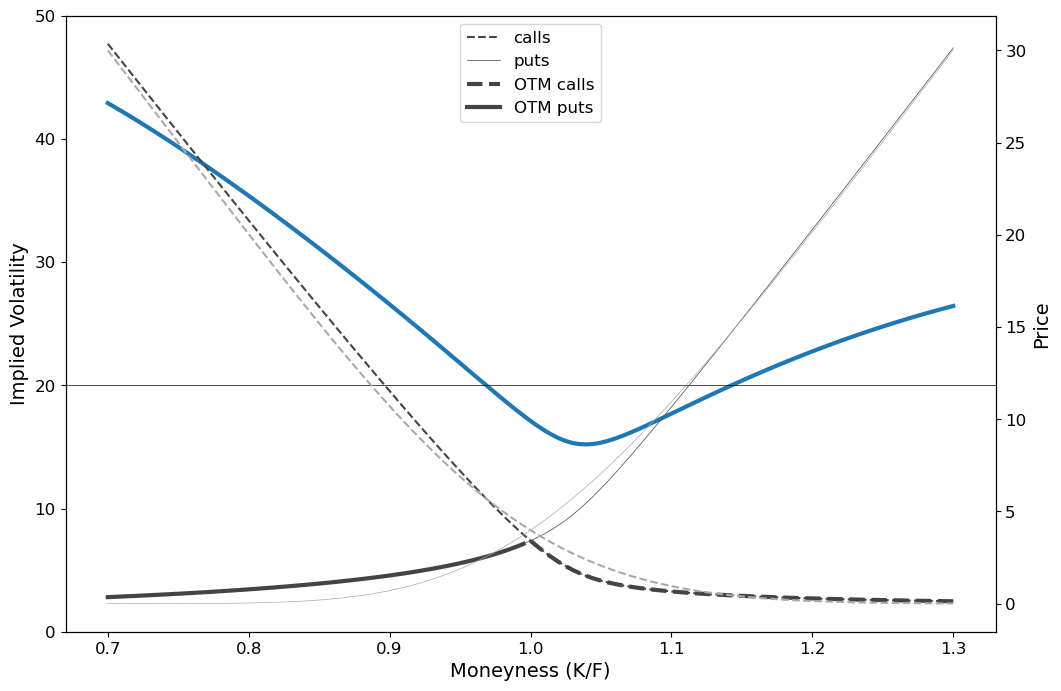

In [5]:
K_asym,c_asym,p_asym = volm.fig_asymmetric_smile(S, K, r, y, T, sigma)
df.savefig('modeling_volatility','fig_asymmetric_smile.pdf')

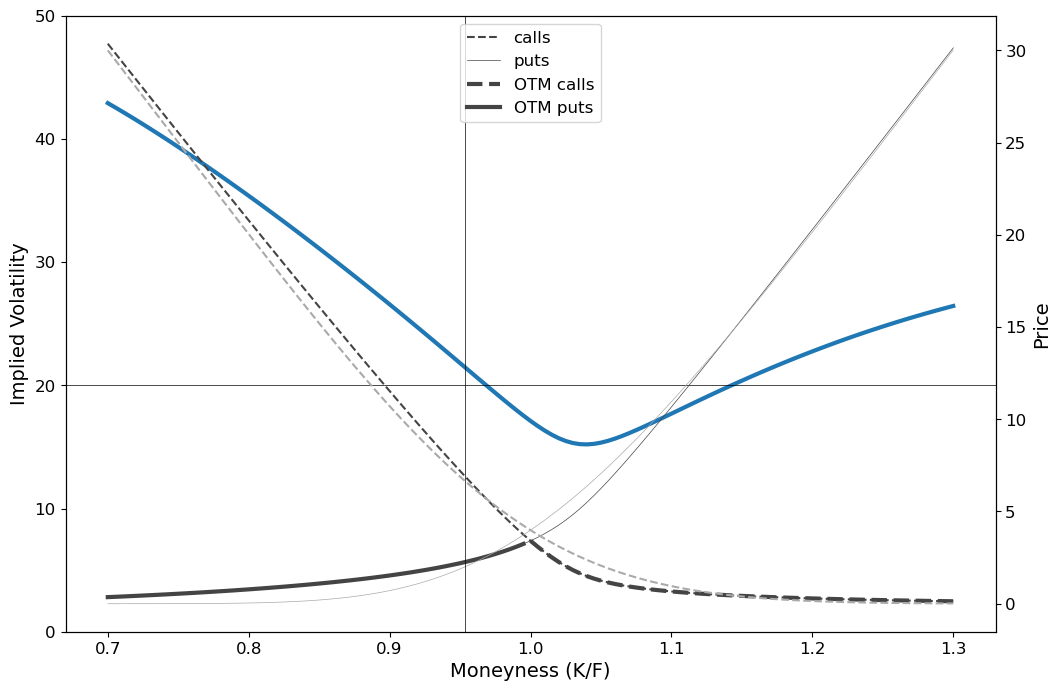

In [6]:
volm.fig_asymmetric_smile(S, K, r, y, T, sigma)
ax = plt.gca()
K70 = moneyness.delta_to_strike(0.7, S, is_call=True)
mny70 = moneyness(S, K70)
ax.axvline(mny70, color='k', linewidth=0.5)
df.savefig('modeling_volatility','fig_asym_smile_delta70.pdf')

## Links with the risk-neutral measure
Consider two calls $c(0,K-1,T)$ and $c(0,K,T)$. Note that payoff of the bull call spread $c(0,K-1,T) - c(0,K,T)$ is 0 whenever $S(T) \le K-1$ and 1 whenever $S(T) \ge K$. If the stock could not take values $S(T) \in (K-1, K)$, the payoff of the bull call spread would essentially be that of the indicator function 
${1}\lbrace S(T) > K-1 \rbrace$. A bull call spread built with $c(0,K,T)$ and $c(0,K+1,T)$ would similarly yield an approximation for ${1}\lbrace S(T) \ge K+1 \rbrace$. 

Combining a long position in the [K-1,K] spread and a short position in the [K,K+1] spread yield a butterfly spread. By Feynman-Kac, neglecting once more the possibility that $S(T)$ take non-integer values, the time-0 value of this butterfly spread is thus:
\begin{align}
    b(0,K,T) 
    & \simeq e^{-rT} \operatorname{E}^\mathbb{Q}\Big[     
    {1}\lbrace S(T) > K-1 \rbrace 
    - {1}\lbrace S(T) \ge K+1 \rbrace
    \Big]\\
    &= e^{-rT}\Big( 
    \operatorname{E}^\mathbb{Q}\left[     
    {1}\lbrace S(T) > K - 1 \rbrace 
    \right]
    - \operatorname{E}^\mathbb{Q}\left[     
    {1}\lbrace S(T) \ge K+1 \rbrace
    \right] \Big)\\
    &= e^{-rT}\Big( 
    \mathbb{Q}\left[ S(T) > K-1 \right] - \mathbb{Q}\left[ S(T) \ge K+1 \right] \Big)\\
    &\simeq e^{-rT}\mathbb{Q}\left[ S(T) = K \right]    
\end{align}
Otherwise stated, the risk-neutral probability that an integer-valued stock has value $K$ at $T$ is 
$e^{rT}b(0,K,T)$. 

Now, of course, stocks are not integer valued. Note, however, that $c(0,K-\Delta K,T) - c(0,K,T)$ spread has a payoff of $\Delta K$ whenever $S(T) > K+\Delta K$. Hence, we could repeat the above analysis with $1/\Delta K$ units of the butterfly spread and obtain:
\begin{align}
    e^{rT}\Pi(0,K,T) = \frac{e^{rT}}{\Delta K} b(0,K,T) 
    &\simeq \frac{
    \mathbb{Q}\left[ S(T) > K-\Delta K \right] 
    - \mathbb{Q}\left[ S(T) > K+\Delta K \right] }{2} .
\end{align} 
For instance, consider 3 calls struck at $K \in \lbrace S-0.50, S, S+0.5\rbrace$. 

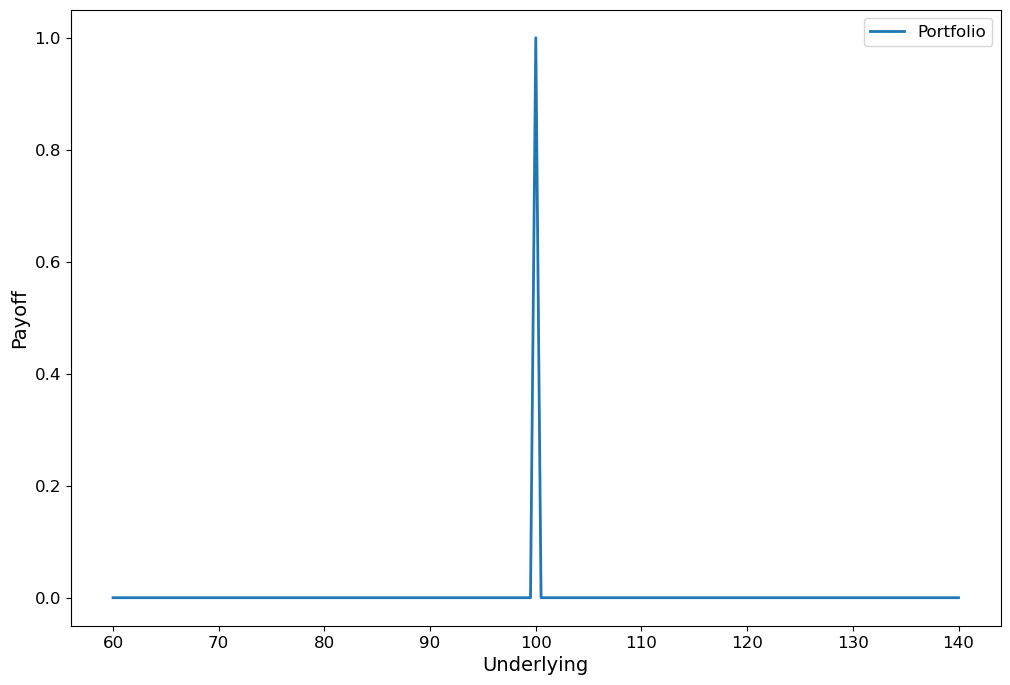

In [7]:
from dorion_francois.instruments import Call, Portfolio

dK = 0.5
K = S
cm1 = Call(S, K-dK, T)
c0 = Call(S, K, T)
cp1 = Call(S, K+dK, T)

S_T = np.arange(0.6*S, 1.401*S, dK).reshape(1,-1)
ptf = (1/dK) * Portfolio((cm1 - c0) - (c0 - cp1)).set_name('butterfly')

fig, ax = plt.subplots(1, 1, figsize=(12,8))
ptf.plot_payoff(ax, S_T);

The area under the curve is 1 (that of a triangle, $bh/2$, with $b=2\Delta K$ and $h=1$). Intuitively, the initial value of this portfolio is the (discounted) probability of cashing this dollar. For $\Delta K$ increasingly small, we would thus get the risk-neutral density of $S(T)$ evaluated at $K$. Formally,
\begin{align}
    \operatorname{d}\mathbb{Q}\left[ S(T) = K \right] 
    &=\lim_{\Delta K \rightarrow 0^+} \frac{
        \mathbb{Q}\left[ S(T) \le K+\Delta K \right] - \mathbb{Q}\left[ S(T) \le K-\Delta K \right]
        }{2\Delta K} 
    = \lim_{\Delta K \rightarrow 0^+} \frac{e^{rT}}{\Delta K}\Pi(0,K,T) \\
    &= \lim_{\Delta K \rightarrow 0^+} \frac{e^{rT}}{(\Delta K)^2}
        \Big([c(0,K+\Delta K,T) - c(0,K,T)] - [c(0,K,T) - c(0,K-\Delta K,T)]\Big) \\ 
    &= e^{rT}\frac{\partial^2 c(0,K,T)}{\partial K^2}.
\end{align}
This powerful result means that the curvature of option prices as a function of moneyness is highly informative about the $\mathbb{Q}$-probability of future stock values. 

Theoretical CDF at K_max: 0.9944574510950038
Empirical CDF at K_max: 0.9944511085870595


(100, 101.25784515406345, 99.74999999997294, 99.74999999997294)

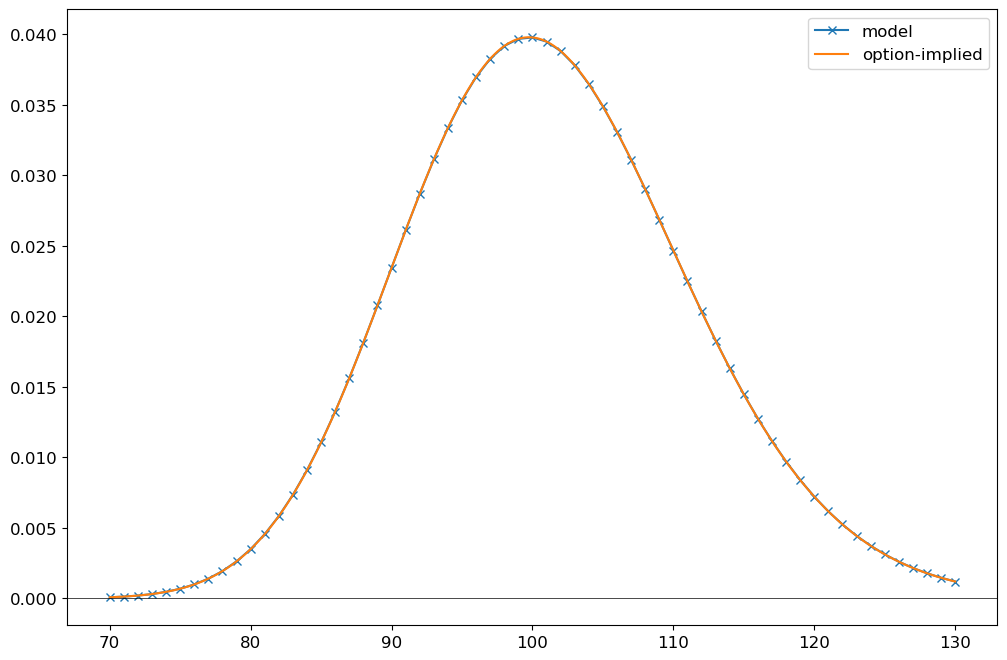

In [8]:
from scipy.stats import norm
from scipy.integrate import trapz

dK = 0.005

# Under BMS
S_T = np.arange(0.7*S, 1.3*S+dK, dK)
if False:
    Z = (np.log(S_T/S) - (r-y-0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    pdf = norm.pdf(Z)
    pdf /= trapz(pdf, S_T) # Total probability is 1.
    # This approach might seem more "intuitive", but yields slightly biased results
else:
    pdf = norm.pdf(bms.d2(S, S_T, r, y, T, sigma)) / (S_T*sigma*np.sqrt(T)) 
    print('Theoretical CDF at K_max:',trapz(pdf, S_T))
    
# Option-implied pdf... from BMS option prices
strikes = S_T
price = bms.option_price(S, strikes, r, y, T, sigma, is_call=True)
b_0 = price[2:] - 2*price[1:-1] + price[:-2]
opt = np.exp(r*T)*b_0 / (dK**2)
print('Empirical CDF at K_max:',trapz(opt, strikes[1:-1]))

fig, ax = plt.subplots(1, 1, figsize=(12,8))
#ax.plot(strikes, pdf, label='model')
ax.plot(strikes[::200], pdf[::200], marker='x', label='model')
ax.plot(strikes[1:-1], opt, label='option-implied')
ax.axhline(0,color='k',linewidth=0.5)
ax.legend();

# Both approaches have their mode slightly below the forward price. 
# The mode of the distribution is below S, whereas the mean is F. This is because
# the log-normal distribution of S_T is right-skewed
F = S*np.exp((r-y)*T)
S, F, S_T[np.argmax(pdf)], S_T[1+np.argmax(opt)] #1+ because strike[0] is excluded

Conceptually, the option-implied distribution in [8] is obtained from the prices matching the flat volatility in the [fig_no_smile] above. 

Whereas we do not know a priori the model that generated the symmetric and asymmetric smiles above, we can apply the Breedan-Litzenberger result to obtain an option-implied risk-neutral distribution.

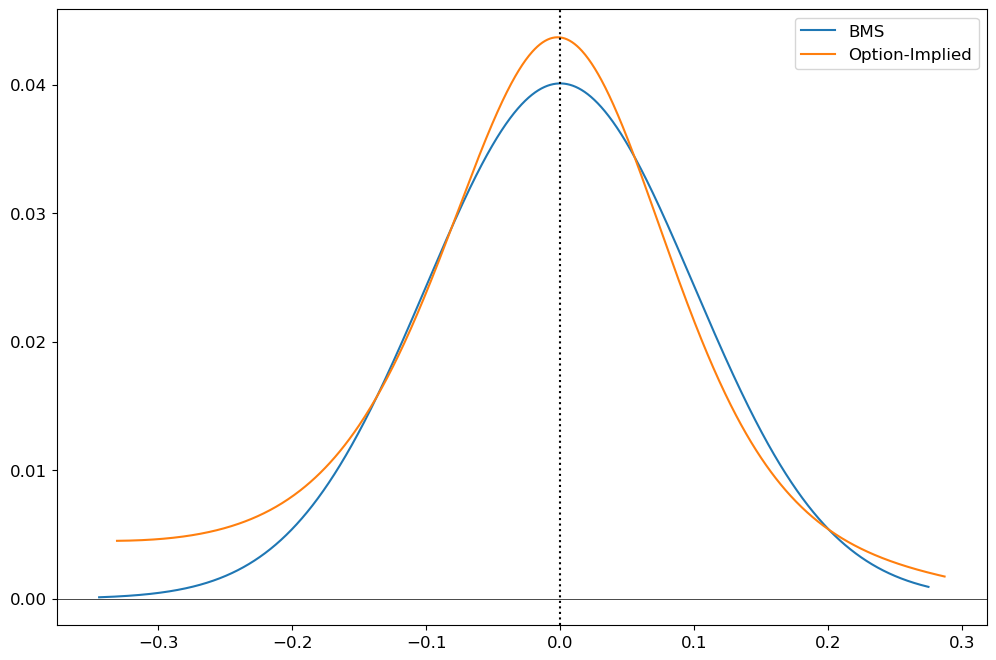

In [9]:
# This call would fail:
#     rnd = volm.BL78_risk_neutral_density(np.exp(r*T), K_sym, c_sym)
# The way the example is set, strikes are not equally spaced. This is not uncommon 
# in (filtered) data. See the implementation of the function below if you are interested.
K,rnd = volm.risk_neutral_density(c_sym, S, K_sym, r, y, T)
fig, ax = plt.subplots(1, 1, figsize=(12,8))
if False:
    ax.plot(strikes, pdf, label='BMS')
    ax.plot(K, rnd, label='Option-Implied')
    ax.axvline(S,color='k',linestyle=':')
else:
    ax.plot(r*T+np.log(strikes/S), S*pdf/strikes, label='BMS')
    ax.plot(r*T+np.log(K/S), S*rnd/K, label='Option-Implied')
    ax.axvline(0,color='k',linestyle=':')
ax.axhline(0,color='k',linewidth=0.5)
ax.legend();

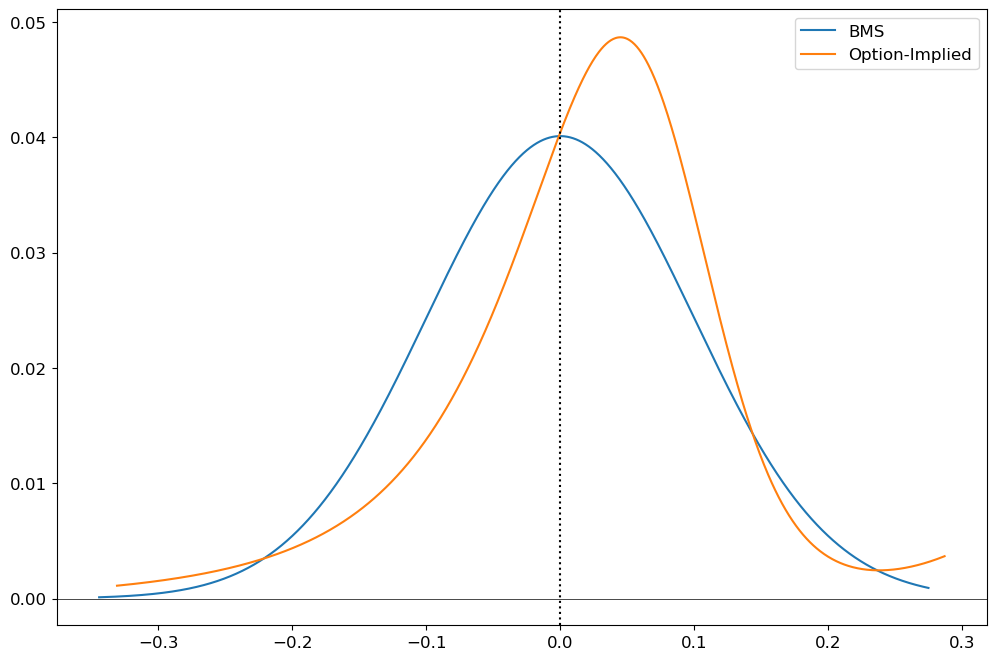

In [10]:
K,rnd = volm.risk_neutral_density(c_asym, S, K_asym, r, y, T)
fig, ax = plt.subplots(1, 1, figsize=(12,8))
if False:
    ax.plot(strikes, pdf, label='BMS')
    ax.plot(K, rnd, label='Option-Implied')
    ax.axvline(S,color='k',linestyle=':')
else:
    ax.plot(r*T+np.log(strikes/S), S*pdf/strikes, label='BMS')
    ax.plot(r*T+np.log(K/S), S*rnd/K, label='Option-Implied')
    ax.axvline(0,color='k',linestyle=':')    
ax.axhline(0,color='k',linewidth=0.5)
ax.legend();

In [11]:
c_asym

array([30.35784308, 29.87432853, 29.39121616, 28.90851526, 28.42621117,
       27.94434266, 27.4629201 , 26.98196924, 26.50150465, 26.02153269,
       25.54205088, 25.06308411, 24.58465677, 24.10680422, 23.62953905,
       23.15286518, 22.67682134, 22.20145504, 21.72678098, 21.25281658,
       20.77958169, 20.30708945, 19.83537619, 19.364485  , 18.89442284,
       18.42522101, 17.95694778, 17.48962384, 17.02334673, 16.55812623,
       16.09404174, 15.63116872, 15.16958342, 14.70931109, 14.25044099,
       13.79305194, 13.33722907, 12.8830841 , 12.43075067, 11.98033003,
       11.53188552, 11.08556233, 10.64154186, 10.20001102,  9.76116408,
        9.32520134,  8.89230046,  8.46279498,  8.03704032,  7.61533846,
        7.19808845,  6.78574122,  6.37876622,  5.97776839,  5.58342094,
        5.1964908 ,  4.81793958,  4.4488788 ,  4.09051817,  3.74432678,
        3.41199164,  3.09555211,  2.79721693,  2.5192414 ,  2.26391798,
        2.0331691 ,  1.82827587,  1.64943436,  1.49517238,  1.36